In [7]:
from mymodels import mobilenet_v3_small, train, test_error, kCV
from dataUtils import *
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
from torch.utils.data import Subset
from torcheval.metrics import R2Score
from torch import nn,optim,save,load,Tensor,cat,no_grad
import matplotlib.pyplot as plt
import time
from torch.cuda import synchronize
device = 'cuda'
netName = 'mobile'

In [7]:
best = load_json(f'HPO/{netName}net_SGD_cv.json')
print(best)
model_params = {'dropout':best['dropout']}
model = mobilenet_v3_small
net = model(**model_params) 
loss_fn = nn.MSELoss
optimizer = optim.SGD
increase_perc = 0
opt_params = {'lr': best['lr'], 'weight_decay':1e-4, 'momentum': best['momentum']}
epochs = 50
batch_size = best['batch_size']
epochs_loss = train(
    net,
    loss_fn(),
    optimizer(net.parameters(),**opt_params),
    epochs,
    make_train_loader(batch_size=batch_size,increase_perc=increase_perc),
    make_validation_loader(batch_size=batch_size),
    device='cuda'
)

{'dropout': 0.3, 'lr': 0.000635339, 'batch_size': 32, 'momentum': 0.85, 'loss': 0.0357152}
EPOCH 1
	train loss:	 0.047164304698310275
	val. loss:	 0.046799788674847645
EPOCH 2
	train loss:	 0.04380315047974634
	val. loss:	 0.04700358711521734
EPOCH 3
	train loss:	 0.04311673596759539
	val. loss:	 0.046552706001834435
EPOCH 4
	train loss:	 0.040710451911286555
	val. loss:	 0.04593533971770243
EPOCH 5
	train loss:	 0.0402986598154991
	val. loss:	 0.04635575879365206
EPOCH 6
	train loss:	 0.03743734952099252
	val. loss:	 0.0477514597163959
EPOCH 7
	train loss:	 0.03615718020476622
	val. loss:	 0.043273728848858314
EPOCH 8
	train loss:	 0.035285756019598775
	val. loss:	 0.03847973565147682
EPOCH 9
	train loss:	 0.033714416722702506
	val. loss:	 0.03980920328335329
EPOCH 10
	train loss:	 0.031808214879935924
	val. loss:	 0.035188041288744316
EPOCH 11
	train loss:	 0.03133128727279087
	val. loss:	 0.03473811080171303
EPOCH 12
	train loss:	 0.02979782999188888
	val. loss:	 0.03269843613220886

In [14]:
dataset = make_train_val_set()
cv_loss = kCV(5,dataset,model,model_params,loss_fn,optimizer,opt_params=opt_params,epochs=epochs,batch_size=batch_size)
save(net.state_dict(), f'models/{netName}_net.pth')

FOLD 0
EPOCH 1
	train loss:	 0.05104510022365317
	val. loss:	 0.050518798008561135
EPOCH 2
	train loss:	 0.04768657887696612
	val. loss:	 0.05066016852855682
EPOCH 3
	train loss:	 0.04586074640024073
	val. loss:	 0.05230374731123447
EPOCH 4
	train loss:	 0.044487350686852424
	val. loss:	 0.05441315732896328
EPOCH 5
	train loss:	 0.041678473524445175
	val. loss:	 0.053850673958659175
EPOCH 6
	train loss:	 0.03903087621972877
	val. loss:	 0.05661078527569771
EPOCH 7
	train loss:	 0.03678033929508256
	val. loss:	 0.054438770040869715
EPOCH 8
	train loss:	 0.03472472537232905
	val. loss:	 0.04609457798302174
EPOCH 9
	train loss:	 0.03250215502873975
	val. loss:	 0.03677497774362564
EPOCH 10
	train loss:	 0.03175302236626039
	val. loss:	 0.030395284108817578
EPOCH 11
	train loss:	 0.02958454133714644
	val. loss:	 0.028399385400116443
EPOCH 12
	train loss:	 0.02881246864111448
	val. loss:	 0.026859600991010667
EPOCH 13
	train loss:	 0.026934306659944812
	val. loss:	 0.028365251831710337
EPOC

In [ ]:
to_json(f'results/{netName}net.json',{**epochs_loss,**{'cv':cv_loss,'test':test_error(net,make_test_set())}})

In [4]:
net = mobilenet_v3_small()
net.load_state_dict(load(f'models/{netName}_net.pth',weights_only=True))

/home/aislab/.local/lib/python3.8/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


<All keys matched successfully>

In [14]:
epochs_loss = load_json(f'results/{netName}net.json')
cv = epochs_loss['cv']
test = epochs_loss['test']
validation = epochs_loss['validation'][-1]
train = epochs_loss['train'][-1]
print(f'train: {train}\nvalid.: {validation}\ntest: {test}\ncv: {cv}')

train: 0.016149302903046406
valid.: 0.018068035133183002
test: 0.017147516149320995
cv: 0.016660159530118106


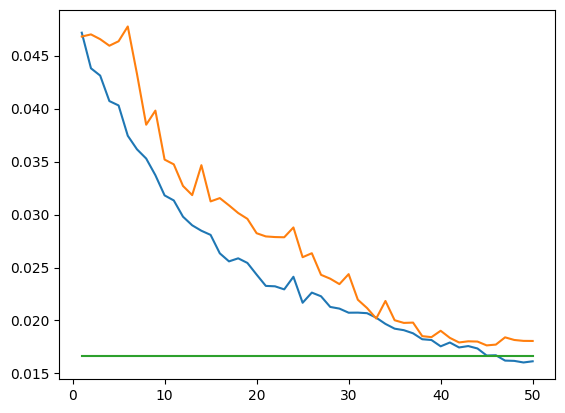

In [19]:
epochs = len(epochs_loss['validation'])
first_epoch = 1
epochsX = range(first_epoch,epochs+1)
plt.plot(epochsX, epochs_loss['train'][first_epoch-1:])
plt.plot(epochsX, epochs_loss['validation'][first_epoch-1:])
plt.plot([first_epoch,epochs], [cv]*2)
#plt.plot([first_epoch,epochs], [test]*2)

In [15]:
testloader = DataLoader(
    make_test_set(), batch_size=1, shuffle=False, num_workers=2
)
net.eval()
total_time = 0
device = 'cuda'
net.to(device)
test_error(net,make_test_set(),device='cuda') #WARM UP
for data in testloader:
    x, area, ate, are = data
    x = x.to(device)
    area = area.to(device)
    ate = ate.to(device)
    are = are.to(device)
    synchronize()
    start_time = time.time()
    outputs = net(x,area)
    synchronize()
    end_time = time.time()
    total_time += (end_time-start_time)/len(data)
inf_time = total_time/len(testloader)
print(f'inference time GPU: {inf_time}')
total_time = 0
device = 'cpu'
net.to(device)
test_error(net,make_test_set(),device='cpu') #WARM UP
for data in testloader:
    x, area, ate, are = data
    x = x.to(device)
    area = area.to(device)
    ate = ate.to(device)
    are = are.to(device)
    synchronize()
    start_time = time.time()
    outputs = net(x,area)
    synchronize()
    end_time = time.time()
    total_time += (end_time-start_time)/len(data)
inf_time = total_time/len(testloader)
print(f'inference time CPU: {inf_time}')

inference time GPU: 0.0005893445806241826
inference time CPU: 0.001446876518998139


In [21]:
param_size = 0
for param in net.parameters():
    param_size += param.nelement() * param.element_size()
buffer_size = 0
for buffer in net.buffers():
    buffer_size += buffer.nelement() * buffer.element_size()

size_all_mb = (param_size + buffer_size) / 1024**2
print('model size: {:.3f}MB'.format(size_all_mb))

model size: 5.863MB


In [5]:
test_load = make_test_loader()
n = len(test_load)
predicted = []
real = []
net.cpu()
net.eval()
with no_grad():
    for map,area,ate,are in test_load:
        yhat = net(map,area).squeeze(0).numpy()
        predicted += [yhat]
        real += [cat([ate,are]).numpy()]

In [10]:
Predicted = np.array([np.array(revert_data_norm(ate,are)) for ate,are in predicted])
Real = np.array([np.array(revert_data_norm(ate,are)) for ate,are in real])
pAte = Predicted[:,0]
pAre = Predicted[:,1]
rAte = Real[:,0]
rAre = Real[:,1]
R2_ate = r2_score(rAte,pAte)
R2_are = r2_score(rAre,pAre)
RMSE_ate = np.sqrt(mean_squared_error(rAte,pAte))
RMSE_are = np.sqrt(mean_squared_error(rAre,pAre))
NRMSE_ate = RMSE_ate/(pAte.max()-pAte.min())
NRMSE_are = RMSE_are/(pAre.max()-pAre.min())
print(f'ATE\n\tR2: {round(R2_ate,3)}\tRMSE: {round(RMSE_ate,3)}\tNRMSE: {round(NRMSE_ate,3)}\t')
print(f'ARE\n\tR2: {round(R2_are,3)}\tRMSE: {round(RMSE_are,3)}\tNRMSE: {round(NRMSE_are,3)}\t')

ATE
	R2: 0.463	RMSE: 1.133	NRMSE: 0.164	
ARE
	R2: 0.846	RMSE: 0.016	NRMSE: 0.078	
